# Actividad 1 corte 2 IA II

* # EDA

In [78]:
# Importamos librerias necesarias

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [59]:
data = pd.read_excel("DataEnergy.xlsx") # Cargamos el dataset
data.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,NaN,NaN,NaN,NaN,2019,2019,2019,2019,2019,2019,2019,2019,2019,2019,2019,2019,2020,2020,2020
1,NaN,NaN,NaN,NaN,1,2,3,4,5,6,7,8,9,10,11,12,1,2,3
2,NaN,NaN,CUENTA CONTRATO,NaN,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes
3,NaN,ATM REMOTO,10001,NaN,159,145,119,145,137,136,122,143,121,144,131,126,114,117,129
4,NaN,ATM REMOTO,10002,NaN,734,145,423,424,521,545,485,558,464,519,476,463,446,460,451


In [60]:
data.info() # Info general, vemos que hay bastantes nulos
data.isnull().sum() # Contamos los null

<class 'pandas.DataFrame'>
RangeIndex: 370 entries, 0 to 369
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   0 non-null      float64
 1   Unnamed: 1   367 non-null    str    
 2   Unnamed: 2   368 non-null    str    
 3   Unnamed: 3   0 non-null      float64
 4   Unnamed: 4   349 non-null    object 
 5   Unnamed: 5   349 non-null    object 
 6   Unnamed: 6   349 non-null    object 
 7   Unnamed: 7   349 non-null    object 
 8   Unnamed: 8   349 non-null    object 
 9   Unnamed: 9   349 non-null    object 
 10  Unnamed: 10  349 non-null    object 
 11  Unnamed: 11  349 non-null    object 
 12  Unnamed: 12  348 non-null    object 
 13  Unnamed: 13  348 non-null    object 
 14  Unnamed: 14  348 non-null    object 
 15  Unnamed: 15  348 non-null    object 
 16  Unnamed: 16  365 non-null    object 
 17  Unnamed: 17  364 non-null    object 
 18  Unnamed: 18  362 non-null    object 
dtypes: float64(2), obje

Unnamed: 0     370
Unnamed: 1       3
Unnamed: 2       2
Unnamed: 3     370
Unnamed: 4      21
Unnamed: 5      21
Unnamed: 6      21
Unnamed: 7      21
Unnamed: 8      21
Unnamed: 9      21
Unnamed: 10     21
Unnamed: 11     21
Unnamed: 12     22
Unnamed: 13     22
Unnamed: 14     22
Unnamed: 15     22
Unnamed: 16      5
Unnamed: 17      6
Unnamed: 18      8
dtype: int64

In [61]:
# Empezamos a limpiar el dataset

dataClean = data.drop(data.columns[[0,3]], axis=1) # Eliminamos las columnas 0 y 3 (1 y 4) las cuales están totalmente vacías
dataClean.head(10)

,Unnamed: 1,Unnamed: 2,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,NaN,NaN,2019,2019,2019,2019,2019,2019,2019,2019,2019,2019,2019,2019,2020,2020,2020
1,NaN,NaN,1,2,3,4,5,6,7,8,9,10,11,12,1,2,3
2,NaN,CUENTA CONTRATO,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes,CONSUMO kWh/mes
3,ATM REMOTO,10001,159,145,119,145,137,136,122,143,121,144,131,126,114,117,129
4,ATM REMOTO,10002,734,145,423,424,521,545,485,558,464,519,476,463,446,460,451
5,OFICINA,10003,4843,4917,4356,4862,4618,4878,5186,5067,4657,4218,3582,3455,3349,3414,2285
6,ATM REMOTO,10004,201,197,2285,2277,2330,2330,2549,2297,2389,2336.571429,2343.938776,2333.644315,246,0,492
7,ATM REMOTO,10005,130,152,0,0,0,0,0,0,0,0,0,0,160.5,0,321
8,ATM REMOTO,10006,402,520,3853,4338,3660,3660,3815,3738,3321,3624.857143,3592.265306,3649.588921,677,0,1354
9,ATM REMOTO,10007,201,197,1278,1260,1235,1235,1486,1093,565,1184.285714,1170.897959,1158.169096,130,0,260


In [62]:
# Vemos que la fila 1 y 2 son el año y mes las unimos para que quede en una solo fila y no tener multiples indices

new_cols = ['TIPO', 'CUENTA_CONTRATO'] # Nombres de la columna 1 y 2

for i in dataClean.columns[2:]: # Recorremos de la columna 3 en adelante
    anio = int(data[i].iloc[0])            # Obtiene el año de la fila 0
    mes = int(data[i].iloc[1])             # Obtiene el mes de la fila 1

    fecha_header = f"{anio}-{mes:02d}" # Formateamos anio + mes con cero a izquierda
    new_cols.append(fecha_header)

dataClean.columns = new_cols # Asignamos los nuevos nombres de columna

dataClean = dataClean.iloc[3:].reset_index(drop=True) # Eliminamos las filas 0, 1 y 2 y reiniciamos el índice
# Sabemos que los numeros representan CONSUMO kWh/mes, por eso lo quitamos de los indices
dataClean.head()

,TIPO,CUENTA_CONTRATO,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03
0,ATM REMOTO,10001,159,145,119,145,137,136,122,143,121,144,131,126,114,117,129
1,ATM REMOTO,10002,734,145,423,424,521,545,485,558,464,519,476,463,446,460,451
2,OFICINA,10003,4843,4917,4356,4862,4618,4878,5186,5067,4657,4218,3582,3455,3349,3414,2285
3,ATM REMOTO,10004,201,197,2285,2277,2330,2330,2549,2297,2389,2336.571429,2343.938776,2333.644315,246,0,492
4,ATM REMOTO,10005,130,152,0,0,0,0,0,0,0,0,0,0,160.5,0,321


In [63]:
# como vimos en dataClean.info() sabemos que los datos están en tipo object y los necesitamos en numeriicos

# Desde la columna 3 en adelante están los consumos
cols_consumo = dataClean.columns[2:]

dataClean[cols_consumo] = dataClean[cols_consumo].apply(pd.to_numeric,errors='coerce')
dataClean.info()
dataClean.isnull().sum() # Vemos que todavia hay datos nulos

<class 'pandas.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TIPO             367 non-null    str    
 1   CUENTA_CONTRATO  367 non-null    str    
 2   2019-01          345 non-null    float64
 3   2019-02          346 non-null    float64
 4   2019-03          345 non-null    float64
 5   2019-04          346 non-null    float64
 6   2019-05          345 non-null    float64
 7   2019-06          346 non-null    float64
 8   2019-07          345 non-null    float64
 9   2019-08          346 non-null    float64
 10  2019-09          344 non-null    float64
 11  2019-10          345 non-null    float64
 12  2019-11          344 non-null    float64
 13  2019-12          345 non-null    float64
 14  2020-01          356 non-null    float64
 15  2020-02          355 non-null    float64
 16  2020-03          352 non-null    float64
dtypes: float64(15), str(2)
memo

In [65]:
# Filtramos las filas donde TODOS los meses son nulos (excluyendo TIPO y CUENTA_CONTRATO)
cuentas_inactivas = dataClean[dataClean.drop(columns=['TIPO', 'CUENTA_CONTRATO']).isna().all(axis=1)]

print(f"Total de cuentas completamente vacías: {len(cuentas_inactivas)}")
print(cuentas_inactivas[['TIPO', 'CUENTA_CONTRATO']])

Total de cuentas completamente vacías: 5
           TIPO CUENTA_CONTRATO
17   ATM REMOTO           10018
19   ATM REMOTO           10020
25   ATM REMOTO           10026
26   ATM REMOTO           10027
315  ATM REMOTO           10316


In [66]:
# Eliminamos las filas por su índice y reiniciamos el índice de la tabla
dataClean = dataClean.drop(index=cuentas_inactivas.index).reset_index(drop=True)
dataClean.isnull().sum()

TIPO                0
CUENTA_CONTRATO     0
2019-01            17
2019-02            16
2019-03            17
2019-04            16
2019-05            17
2019-06            16
2019-07            17
2019-08            16
2019-09            18
2019-10            17
2019-11            18
2019-12            17
2020-01             6
2020-02             7
2020-03            10
dtype: int64

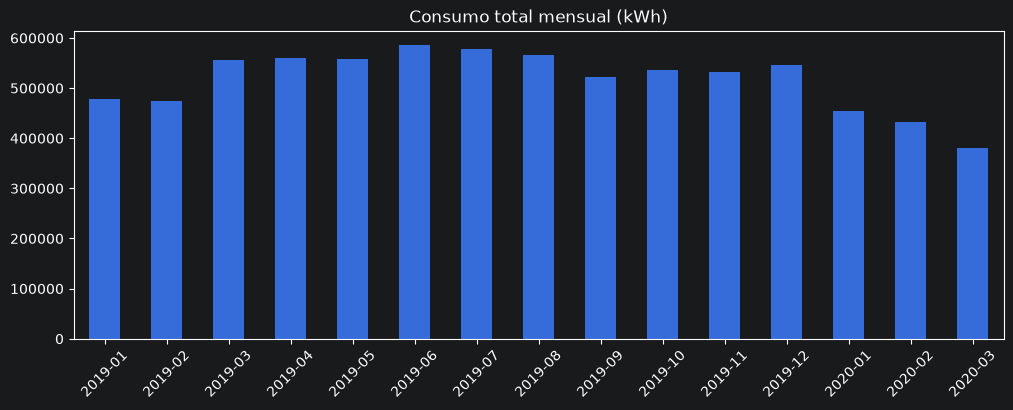

In [67]:
# Consumo total por mes
cols = dataClean.columns[2:]

dataClean[cols].sum().plot(kind='bar', figsize=(12,4), title='Consumo total mensual (kWh)')
plt.xticks(rotation=45)
plt.show()

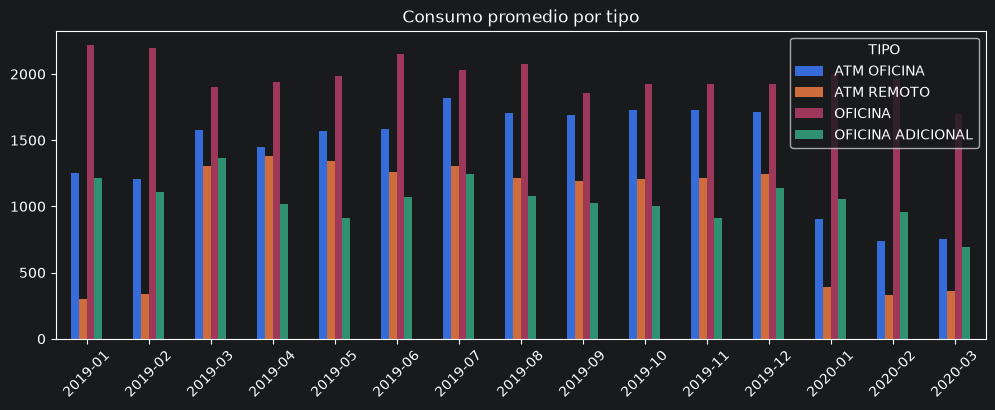

In [68]:
# Consumo promedio por TIPO en el tiempo
dataClean.groupby('TIPO')[cols].mean().T.plot(kind='bar', figsize=(12,4),title='Consumo promedio por tipo')
plt.xticks(rotation=45)
plt.show()

In [69]:
# Validamos todos los nulos en las filas

resumen_nulos = dataClean[["CUENTA_CONTRATO"]].copy()
resumen_nulos["meses_nulos"] = (dataClean.loc[:, "2019-01":"2020-03"].isnull().sum(axis=1))

resumen_nulos

,CUENTA_CONTRATO,meses_nulos
0,10001,0
1,10002,0
2,10003,0
3,10004,0
4,10005,0
...,...,...
357,10363,0
358,10364,0
359,10365,0
360,10366,0


In [70]:
# Con esto sabemos que cuentas tienen datos nulos y cuantos

cuentas_con_nulos = resumen_nulos.loc[resumen_nulos["meses_nulos"] > 0].sort_values("meses_nulos", ascending=False)

cuentas_con_nulos

,CUENTA_CONTRATO,meses_nulos
12,10013,12
19,10022,12
41,10046,12
38,10043,12
46,10051,12
45,10050,12
107,10112,12
84,10089,12
49,10054,12
71,10076,12


In [71]:
# Dividimos las cuentas con datos suficientes e insuficientes

meses = dataClean.loc[:, "2019-01":"2020-03"]

resumen_cuentas = dataClean[["TIPO", "CUENTA_CONTRATO"]].copy()
resumen_cuentas["meses_con_dato"] = meses.count(axis=1)
resumen_cuentas["meses_nulos"] = meses.isnull().sum(axis=1)

cuentas_suficientes = resumen_cuentas.loc[
    resumen_cuentas["meses_con_dato"] >= 12
]

cuentas_limitadas = resumen_cuentas.loc[
    resumen_cuentas["meses_con_dato"] < 12
]

print("Cuentas con datos suficientes:", len(cuentas_suficientes))
print("Cuentas con datos limitados:", len(cuentas_limitadas))

cuentas_limitadas.sort_values("meses_con_dato")

Cuentas con datos suficientes: 344
Cuentas con datos limitados: 18


,TIPO,CUENTA_CONTRATO,meses_con_dato,meses_nulos
12,ATM REMOTO,10013,3,12
19,ATM REMOTO,10022,3,12
38,ATM REMOTO,10043,3,12
41,ATM REMOTO,10046,3,12
45,ATM REMOTO,10050,3,12
46,ATM REMOTO,10051,3,12
49,OFICINA ADICIONAL,10054,3,12
71,ATM REMOTO,10076,3,12
223,OFICINA,10228,3,12
84,OFICINA,10089,3,12


In [72]:
# Etiquetamos los datos para prepararlos para el modelo

meses = dataClean.loc[:, "2019-01":"2020-03"].columns
etiquetas = dataClean[["CUENTA_CONTRATO"]].copy()

for i in range(2, len(meses)):
    anterior_2 = dataClean[meses[i - 2]]
    anterior_1 = dataClean[meses[i - 1]]
    actual = dataClean[meses[i]]

    validos = (anterior_2 > 0) & (anterior_1 > 0) & (actual > 0)
    umbral = 1.30 * (anterior_2 + anterior_1) / 2

    etiquetas[meses[i]] = None
    etiquetas.loc[validos, meses[i]] = "Esperado"
    etiquetas.loc[validos & (actual > umbral), meses[i]] = "Inusualmente alto"

etiquetas.head(100)

,CUENTA_CONTRATO,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03
0,10001,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado
1,10002,Esperado,Inusualmente alto,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado
2,10003,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado
3,10004,Inusualmente alto,Inusualmente alto,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,None,None
4,10005,None,None,None,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,10100,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado
96,10101,Esperado,Inusualmente alto,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Inusualmente alto,Esperado,Esperado
97,10102,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado
98,10103,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Inusualmente alto,Esperado,Esperado,Esperado,Esperado,Esperado


In [75]:
meses = dataClean.loc[:, "2019-01":"2020-03"].columns

# 1. Una sola tabla: dos consumos anteriores y la etiqueta del mes siguiente
historico = pd.concat([
    pd.DataFrame({
        "mes": meses[i],
        "mes_1": dataClean[meses[i - 2]],
        "mes_2": dataClean[meses[i - 1]],
        "etiqueta": etiquetas[meses[i]]
    })
    for i in range(2, len(meses))
], ignore_index=True).dropna(subset=["etiqueta"])

# 2. Separación temporal
train = historico[historico["mes"] <= "2020-01"]
test = historico[historico["mes"] >= "2020-02"]

# 3. Entrenar sin mostrarle febrero ni marzo de 2020
modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
modelo.fit(train[["mes_1", "mes_2"]], train["etiqueta"])

# 4. Evaluar con febrero y marzo
predichas = modelo.predict(test[["mes_1", "mes_2"]])

print("Casos de entrenamiento:", len(train))
print("Casos de prueba:", len(test))
print(classification_report(test["etiqueta"], predichas, zero_division=0))
print(confusion_matrix(
    test["etiqueta"], predichas,
    labels=["Esperado", "Inusualmente alto"]
))

Casos de entrenamiento: 3162
Casos de prueba: 540
                   precision    recall  f1-score   support

         Esperado       0.91      1.00      0.95       489
Inusualmente alto       0.80      0.08      0.14        51

         accuracy                           0.91       540
        macro avg       0.86      0.54      0.55       540
     weighted avg       0.90      0.91      0.88       540

[[488   1]
 [ 47   4]]


In [76]:
modelo.fit(historico[["mes_1", "mes_2"]], historico["etiqueta"])

validos = (dataClean["2020-02"] > 0) & (dataClean["2020-03"] > 0)
etiquetas["2020-04"] = None

etiquetas.loc[validos, "2020-04"] = modelo.predict(
    dataClean.loc[validos, ["2020-02", "2020-03"]]
    .set_axis(["mes_1", "mes_2"], axis=1)
)

In [77]:
# Entrenar de nuevo con todo el histórico conocido
modelo.fit(historico[["mes_1", "mes_2"]], historico["etiqueta"])

# Crear la nueva tabla
tabla_final = etiquetas.copy()
tabla_final["2020-04"] = None

# Predecir solo si febrero y marzo tienen lecturas positivas
validos = (dataClean["2020-02"] > 0) & (dataClean["2020-03"] > 0)

tabla_final.loc[validos, "2020-04"] = modelo.predict(
    dataClean.loc[validos, ["2020-02", "2020-03"]]
    .set_axis(["mes_1", "mes_2"], axis=1)
)

tabla_final

,CUENTA_CONTRATO,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04
0,10001,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado
1,10002,Esperado,Inusualmente alto,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado
2,10003,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado
3,10004,Inusualmente alto,Inusualmente alto,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,Esperado,None,None,None
4,10005,None,None,None,None,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,10363,None,None,None,Esperado,Esperado,Esperado,None,None,None,Esperado,Esperado,Esperado,Esperado,Esperado
358,10364,None,None,None,None,None,None,None,None,None,None,None,None,Esperado,Esperado
359,10365,Esperado,Esperado,Esperado,Esperado,Esperado,None,None,None,None,Esperado,Inusualmente alto,Esperado,Esperado,Esperado
360,10366,None,None,None,None,None,None,None,None,None,None,None,None,Inusualmente alto,Esperado
